<a href="https://colab.research.google.com/github/jccrews256/Final-Project/blob/main/Homework%204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 4
*By: Cass Crews*

## Part 1: Summarizing Student Data Graphically

For the first part of homework 4, we will continue our exploratory data analysis of student math scores from two Portuguese schools. Thus, the numerical summaries generated for homework 3 are included below for reference.

Before we begin, we need to read in the required modules.

In [1]:
# Reading in required modules
import pandas as pd
import matplotlib.pyplot as plt

### Summarizing Data Numerically (From Homework 3)

For the second part of this homework, we will explore student math performance across two different Portuguese schools.

#### Reading in the Data

Our first step is to read in the data directly from the URL. We'll need to account for the fact that these data are semicolon-delimited using the `sep` argument of `pd.read_csv()`. After reading in the data, we will print the first five rows to ensure things were read in correctly.

In [2]:
# Reading in the data
student_data = pd.read_csv("https://www4.stat.ncsu.edu/~online/datasets/StudentData.txt", sep = ";")

# Printing the first few rows
student_data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In looking at the first few rows, as well as the first and final 10 columns, it seems the data read in cleanly.

#### Summarizing the Data

Now that we have read the data in, we will generate a few numeric summaries. The first set of summaries will focus on the categorical variables, before we transition to the numeric variables.

##### Categorical Variables

We will use contingency tables to explore the categorical variables.

Let's start with a one-way table displaying the number of students from each school. While I don't know much about Portuguese schools, we can still swap to school labels that provide the full school names for people who are knowledgeable. To make this update, we will need to convert `school` to a category type and identify its initial categories.

In [3]:
# Converting school to category type
student_data.school = student_data.school.astype("category")

# Identifying categories for school
student_data.school.cat.categories

Index(['GP', 'MS'], dtype='object')

Now that we know the categories and their order, we can swap in the full school names and generate the contingency table.

In [4]:
# Creating a categorical version of school
student_data.school = student_data.school.cat.rename_categories(["Gabriel Pereira", "Mousinho da Silveira"])

# one-way contingency table for school
student_data.school.value_counts()

,count
school,
Gabriel Pereira,349
Mousinho da Silveira,46


It is notable that 349 out of the 395 students are from one school -- Gabriel Pereira. We need to be cognizant of the fact that student performance at this school will dominate many of the summary statistics we explore.

As one way of exploring how these schools may be different, let's explore the rates at which each offers extra educational support to the students via a two-way contingency tabl. As it's good practice, we will also convert `schoolsup` to category type.

In [5]:
# Converting schoolsup to category type
student_data.schoolsup = student_data.schoolsup.astype("category")

In [6]:
# two way contingency table for school and schoolsup
pd.crosstab(student_data.school,
            student_data.schoolsup,
            margins = True,
            rownames = ["School"],
            colnames = ["Extra Edu Support?"])

Extra Edu Support?,no,yes,All
School,,,
Gabriel Pereira,298,51,349
Mousinho da Silveira,46,0,46
All,344,51,395


This is a stark contrast! While 51 of the 349 students from Gabriel Pereira receive extra educational support, none of the students from Mousinho da Silveira receive extra support.

Now let's explore, by school, the relationship between participation in extra-curricular activities and the number of past class failures. Again, to align with best practices, we will convert `activities` and `failures` to category types. Because a value of 4 for `failures` actually means 4+ failures, we may need to tweak the labels accordingly.

In [7]:
# Converting activities to category type
student_data.activities = student_data.activities.astype("category")

# Converting failures to category type
student_data.failures = student_data.failures.astype("category")

# Printing categories for failures
student_data.failures.cat.categories

Index([0, 1, 2, 3], dtype='int64')

It turns out no student failed more than three classes, so no tweaks are needed. We are now ready to create the three-way contingency table.

In [8]:
# Three way contingency table for school, activities, and failures
pd.crosstab([student_data.school, student_data.activities],
            student_data.failures,
            margins = True,
            rownames = ["School", "Extracurric Activities?"],
            colnames = ["Past Failures"])

Past Failures                                   0   1   2   3  All
School               Extracurric Activities?                      
Gabriel Pereira      no                       130  18   7   9  164
                     yes                      150  23   7   5  185
Mousinho da Silveira no                        20   6   2   2   30
                     yes                       12   3   1   0   16
All                                           312  50  17  16  395

Given the differing school sizes, it's not particularly easy to make comparisons. However, by simply comparing no-failure rates between Gabriel Pereira students who do and do not participate in extra-curricular activities, we see a failure rate of 100\*(130/164)=79% for those who don't participate vs. 100\*(150/185)=81% for those who do. Thus, it doesn't seem extra-curricular participation is a great indicator of past school performance.

Another question we can explore is whether living in a rural or urban setting is related to whether or not a student's family provides educational support, and whether this relationship differs by the sex of the student. To start this exploration, let's create a two-way contingency table for rural/urban and family support specifically for females by using `.loc[]` to create a female-only subset. Before doing so, we should convert `sex` to a category-type variable and give more informative labels; we will use this variable a lot. As a first step, we will make the conversion and see how the categories are currently saved.

In [9]:
# Converting sex to category
student_data.sex = student_data.sex.astype("category")

# Printing categories
student_data.sex.cat.categories

Index(['F', 'M'], dtype='object')

Now we can update the category labels, create the female-only subset, and produce the contingency table.

In [10]:
# Giving sex more informative labels
student_data.sex = student_data.sex.cat.rename_categories(["Female", "Male"])

# Converting address and famsup to categories
student_data.address = student_data.address.astype("category")
student_data.famsup = student_data.famsup.astype("category")

# Subsetting to female students
student_data_female = student_data.loc[student_data.sex == "Female"]

# Two-way contingency table for address (type) and famsup, for females only
pd.crosstab(student_data_female.address,
            student_data_female.famsup,
            margins = True,
            rownames = ["Rural/Urban"],
            colnames = ["Family Edu Support?"])

Family Edu Support?,no,yes,All
Rural/Urban,,,
R,15,29,44
U,51,113,164
All,66,142,208


There are no major difference in the rates of family support between rural- and urban-based females, as 100\*(29/44)=66% of rural-based female students compared to 100\*(113/164)=69% for urban-based females.

How about for male students? To create this conditional table, let's create a three-way contingency table for sex, family support, and rural/urban status and then subset the table.

In [11]:
# Creating three-way table for sex, famsup, and address (type)
table_3 = pd.crosstab([student_data.address, student_data.sex],
                      student_data.famsup,
                      margins = True,
                      rownames = ["Rural/Urban", "Sex"],
                      colnames = ["Family Edu Support?"]
                        )
# Printing table subset to only male students
table_3.loc[(("R","U"), "Male"), : ]

,Family Edu Support?,no,yes,All
Rural/Urban,Sex,,,
R,Male,21,23,44
U,Male,66,77,143


Similar to females, there are effectively no differences in family support between rural and urban males; just over half of rural male students receive family support (100\*(23/44)=52%), compared to 100\*(77/143)=54% of urban males.

It seems the major differences in family support are between male and female students, regardless of their rural/urban status.

##### Numerical Variables

In this subsection, we will calculate measures of center and spread for a few numeric variables in the dataset, repeat the calculations conditional on categorical variables, and analyze pairwise correlations.

To start, let's calculate the mean, median, and standard deviation of `age`, `absences`, and `G3` (final grade).

Means:

In [12]:
# Means of age, absences, and G3
student_data[["age", "absences", "G3"]].mean()

,0
age,16.696203
absences,5.708861
G3,10.415190


Medians:

In [13]:
# Medians of age, absences, and G3
student_data[["age", "absences", "G3"]].median()

,0
age,17.0
absences,4.0
G3,11.0


Standard deviations:

In [14]:
# Standard deviations of age, absences, and G3
student_data[["age", "absences", "G3"]].std()

,0
age,1.276043
absences,8.003096
G3,4.581443


Looking at these statistics, the most notable finding may be the fact that the standard deviation for the number of absences is well above the mean number and twice the median.

How many days are some students missing? Let's extract the maximum number to quell our (my) curiosity.

In [15]:
# Max number of absences
student_data.absences.max()

75

75 days?! Yikes!

Let's again subset the dat to only female and see how the statistics change.

Means:

In [16]:
# Means of age, absences, and G3 for females only
student_data.loc[student_data.sex == "Female"][["age", "absences", "G3"]].mean()

,0
age,16.730769
absences,6.216346
G3,9.966346


Medians:

In [17]:
# Medians of age, absences, and G3 for females only
student_data.loc[student_data.sex == "Female"][["age", "absences", "G3"]].median()

,0
age,17.0
absences,4.0
G3,10.0


Standard deviations:

In [18]:
# Standard deviations of age, absences, and G3 for females only
student_data.loc[student_data.sex == "Female"][["age", "absences", "G3"]].std()

,0
age,1.201696
absences,9.445819
G3,4.622338


While the female-only age statistics are comparable to those overall, the mean number of absences is higher for the female-only subgroup and both measures of center (mean and median) for final math grade are lower for the subgroup.

How do the overall statistic values compare across the two schools? Let's find out starting with `age`.

In [19]:
# Generating summary stats for age by school
pd.pivot_table(student_data, values = "age", index = "school",
               aggfunc = ["mean", "median", "std"], observed = False)

,mean,median,std
,age,age,age
school,,,
Gabriel Pereira,16.521490,16.0,1.216610
Mousinho da Silveira,18.021739,18.0,0.881643


Interestingly, students and Mousinho da Silveira are much older. I wonder why. This is the same school with a much smaller roster....

Let's look at absences!

In [20]:
# Generating summary stats for absences by school
pd.pivot_table(student_data, values = "absences", index = "school",
               aggfunc = ["mean", "median", "std"], observed = False)

,mean,median,std
,absences,absences,absences
school,,,
Gabriel Pereira,5.965616,4.0,8.341764
Mousinho da Silveira,3.760870,3.0,4.274913


Meanwhile, students of the larger Gabriel Pereira tend to have more absences, and the higher standard deviation indicates the school likely has more of the very-high-absence students.

Last, let's look at final math grades.

In [21]:
# Generating summary stats for G3 by school
pd.pivot_table(student_data, values = "G3", index = "school",
               aggfunc = ["mean", "median", "std"], observed = False)

,mean,median,std
,G3,G3,G3
school,,,
Gabriel Pereira,10.489971,11.0,4.625397
Mousinho da Silveira,9.847826,10.0,4.237229


While students at Gabriel Pereira tend to have more absences, they also perform better, on average, in math class.

Let's find out how family educational support (`famsup`) relates to these numeric variables at each school. Again, we will start with `age`.

In [22]:
# Generating summary stats for age by school and famsup
pd.pivot_table(student_data, values = "age", index = ["school", "famsup"],
               aggfunc = ["mean", "median", "std"], observed = False)

mean median       std
                                   age    age       age
school               famsup                            
Gabriel Pereira      no      16.664000   17.0  1.282286
                     yes     16.441964   16.0  1.173790
Mousinho da Silveira no      18.071429   18.0  0.857584
                     yes     17.944444   18.0  0.937595

Not too surprisingly, the age statistics vary little across family support. It is somewhat intriguing that, at both schools, the mean is slightly smaller for those with family support. One or two child prodigies with good family support? Ah, probably not!

Onto `absences`!

In [23]:
# Generating summary stats for absences by school and famsup
pd.pivot_table(student_data, values = "absences", index = ["school", "famsup"],
               aggfunc = ["mean", "median", "std"], observed = False)

mean   median       std
                             absences absences  absences
school               famsup                             
Gabriel Pereira      no      5.944000      4.0  9.048529
                     yes     5.977679      4.0  7.941176
Mousinho da Silveira no      3.321429      2.0  3.906818
                     yes     4.444444      4.0  4.829106

This is a bit more intriguing. At Gabriel Pereira, the mean and median number of absences are fairly similar across those with and without family support; the standard deviation is roughly one absence higher for those with family support. Meanwhile, at Mousinho da Silveira, the mean and median absences for those with family support are both well above those without family support. I can't say I saw that coming!

And now, final grades!

In [24]:
# Generating summary stats for absences by school and famsup
pd.pivot_table(student_data, values = "G3", index = ["school", "famsup"],
               aggfunc = ["mean", "median", "std"], observed = False)

mean median       std
                                    G3     G3        G3
school               famsup                            
Gabriel Pereira      no      10.864000   11.0  4.611249
                     yes     10.281250   11.0  4.630413
Mousinho da Silveira no       9.642857   10.0  4.699994
                     yes     10.166667   10.0  3.502100

This is truly interesting. At Gabriel Pereira, the average final grade for those with family educational support is more than half a unit below those without. At Mousinho da Silveira, the opposite is true. It should be noted that at both schools, the medians are identical for those with and without family support. Thus, there could be a few outliers influencing these per-school differences in means.

We've explored how a few of the numeric variables relate to categorical variables, but how are they related to each other? Let's find out by generating a table of pairwise correlations.

In [25]:
# Generating pairwise correlation table
student_data[["age", "absences", "G1", "G2", "G3"]].corr()

,age,absences,G1,G2,G3
age,1.000000,0.175230,-0.064081,-0.143474,-0.161579
absences,0.175230,1.000000,-0.031003,-0.031777,0.034247
G1,-0.064081,-0.031003,1.000000,0.852118,0.801468
G2,-0.143474,-0.031777,0.852118,1.000000,0.904868
G3,-0.161579,0.034247,0.801468,0.904868,1.000000


I am surprised to see effectively no correlation between the number of absences and the final math grade. Of course, we'll want to plot some of these relationships to ensure we are not trying to measure linear relationships when the relationships are actually non-linear.

### Task 1: Graphical Summaries

We will now summarize the data graphically to gain further understanding of the variables' distributions.

#### Categorical Variables

Let's begin with the categorical variables. We previously explored the patterns of family education support by rural/urban status for each of female and male students. Let's create some comparative bar plot equivalents of those contingency tables.

For the female-only bar plot, let's use a stacked bar plot.

Text(0.5, 1.0, 'Female Student Breakdown by Family Support and Rural/Urban Status')

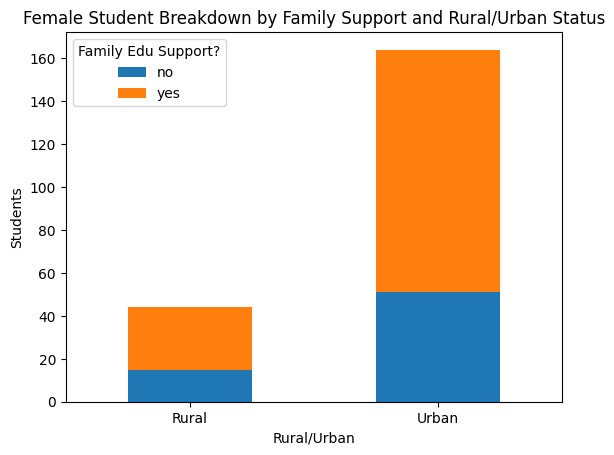

In [40]:
# Two-way contingency table for address (type) and famsup, for females only
female_table = pd.crosstab(student_data_female.address,
            student_data_female.famsup,
            rownames = ["Rural/Urban"],
            colnames = ["Family Edu Support?"])

# Generating stacked bar plot
female_table.plot.bar(stacked = True, rot = 0)
plt.xticks([0, 1], ["Rural", "Urban"]) # Adding clean labels
plt.ylabel("Students") # Adding y axis label
# Adding title
plt.title("Female Student Breakdown by Family Support and Rural/Urban Status")

We can now easily see that while there are many more female students living in urban areas than rural areas, family support rates are roughly the same.

Let's look at the same breakdown for male students, but let's use a side-by-side bar plot this time.

Text(0.5, 1.0, 'Male Student Breakdown by Family Support and Rural/Urban Status')

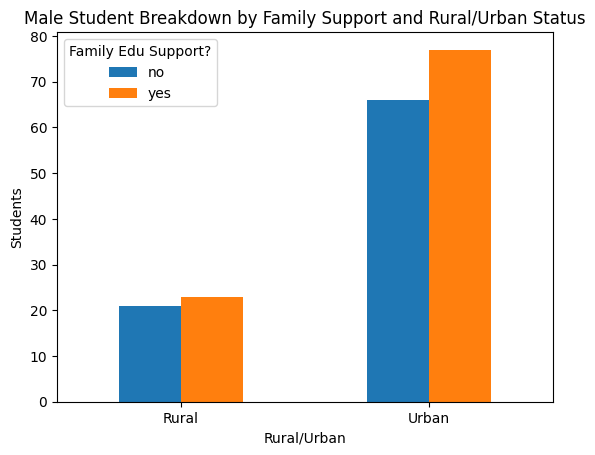

In [43]:
# Subsetting to male students
student_data_male = student_data.loc[student_data.sex == "Male"]

# Two-way contingency table for address (type) and famsup, for males only
male_table = pd.crosstab(student_data_male.address,
            student_data_male.famsup,
            rownames = ["Rural/Urban"],
            colnames = ["Family Edu Support?"])

# Generating stacked bar plot
male_table.plot.bar(rot = 0)
plt.xticks([0, 1], ["Rural", "Urban"]) # Adding clean labels
plt.ylabel("Students") # Adding y axis label
# Adding title
plt.title("Male Student Breakdown by Family Support and Rural/Urban Status")

I find side-by-side bar plots easier to read, as in group comparisons (e.g., rural only) are easier.

We clearly see what we concluded when studying the contingency tables: Rural/urban status also does not seem to impact family support rates for male students, but male students are less likely to receive family education support than their female counterparts.

#### Numeric Variables

Let's visually explore some of the numeric variables. To start, let's generate comparative histograms, kernel density plots, and boxplots exploring the distributions of final grades, or `G3`, for each school.